# Proyek Klasifikasi Gambar: Rice dataset
- **Nama:** Muhammad Rafif Pasya
- **Email:** Rafiffiko18@gmail.com
- **ID Dicoding:** Muhammad Rafif Pasya


## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install kagglehub tensorflowjs

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import tensorflow as tf
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os
import subprocess
import kagglehub
import shutil
import random
from tensorflow.keras.preprocessing import image

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [4]:
!pip install pipreqs
!python -m pipreqs.pipreqs . --force --scan-notebooks

Defaulting to user installation because normal site-packages is not writeable


Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in .\requirements.txt


## Data Preparation

### Data Loading

In [3]:
destination_path = './rice-dataset'
source_dataset_path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
print(f"Dataset berhasil diunduh. {destination_path}...")
if os.path.exists(os.path.join(source_dataset_path, 'Rice_Image_Dataset')):
    source_dataset_path = os.path.join(source_dataset_path, 'Rice_Image_Dataset')

os.makedirs(destination_path, exist_ok=True)
classes = [d for d in os.listdir(source_dataset_path) if os.path.isdir(os.path.join(source_dataset_path, d))]

for class_name in classes:
    source_class_dir = os.path.join(source_dataset_path, class_name)
    dest_class_dir = os.path.join(destination_path, class_name)
    os.makedirs(dest_class_dir, exist_ok=True)

    images = [f for f in os.listdir(source_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images_to_copy = images[:2000] # Ambil 2000 gambar per kelas (total 10.000 gambar)

    for img in images_to_copy:
        src_file = os.path.join(source_class_dir, img)
        dst_file = os.path.join(dest_class_dir, img)
        if not os.path.exists(dst_file):
            shutil.copy2(src_file, dst_file)

dataset_path = destination_path
data_dir = pathlib.Path(dataset_path)

image_count = len(list(data_dir.rglob('*.jpg')) + list(data_dir.rglob('*.jpeg')) + list(data_dir.rglob('*.png')))
print(f"\nTotal gambar  : {image_count}")


Dataset berhasil diunduh. ./rice-dataset...

Total gambar  : 10000


In [38]:
print(" Distribusi Data ")
classes = os.listdir(data_dir)
class_counts = []

for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    if os.path.isdir(class_dir):
        count = len(os.listdir(class_dir))
        class_counts.append(count)
        print(f"Kelas '{class_name}': {count} gambar")

plt.figure(figsize=(10, 5))
plt.bar(classes, class_counts, color='skyblue')
plt.title('Distribusi Jumlah Gambar ')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.show()

 Distribusi Data 
Kelas 'Arborio': 2000 gambar
Kelas 'Basmati': 2000 gambar
Kelas 'Ipsala': 2000 gambar
Kelas 'Jasmine': 2000 gambar
Kelas 'Karacadag': 2000 gambar



 Sampel Gambar 


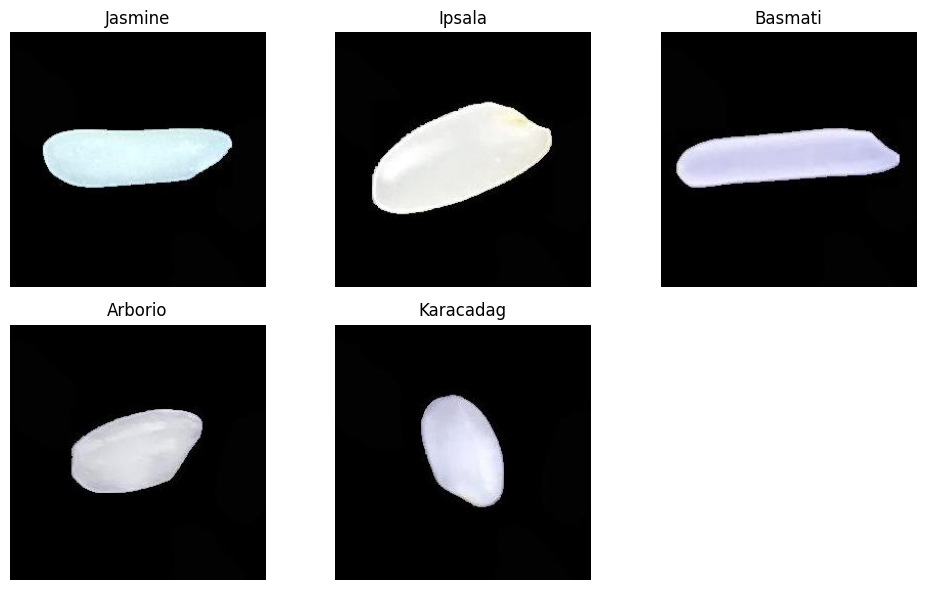

In [39]:
print("\n Sampel Gambar ")
plt.figure(figsize=(10, 6))

for i, class_name in enumerate(classes[:5]):
    class_dir = os.path.join(data_dir, class_name);
    if os.path.isdir(class_dir):
        sample_image = os.listdir(class_dir)[0]
        img_path = os.path.join(class_dir, sample_image)

        img = mpimg.imread(img_path)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

### Data Preprocessing

In [40]:
batch_size = 32
img_height = 150
img_width = 150

print(f"Ukuran Batch: {batch_size}")
print(f"Target Resolusi Gambar: {img_height}x{img_width}")

Ukuran Batch: 32
Target Resolusi Gambar: 150x150


#### Split Dataset

In [41]:
batch_size = 32
img_height = 150
img_width = 150

print("Membagi Dataset (dengan crop_to_aspect_ratio=True untuk menjaga aspek rasio)")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  crop_to_aspect_ratio=True)

val_and_test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  crop_to_aspect_ratio=True)

class_names = train_ds.class_names
print(f"\nKelas yang ditemukan: {class_names}")

val_batches = tf.data.experimental.cardinality(val_and_test_ds)
val_ds = val_and_test_ds.take(val_batches // 2)
test_ds = val_and_test_ds.skip(val_batches // 2)

print(f"\nDistribusi Batch Akhir:")
print(f"- Jumlah batch Training: {tf.data.experimental.cardinality(train_ds)}")
print(f"- Jumlah batch Validation: {tf.data.experimental.cardinality(val_ds)}")
print(f"- Jumlah batch Testing: {tf.data.experimental.cardinality(test_ds)}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Membagi Dataset (dengan crop_to_aspect_ratio=True untuk menjaga aspek rasio)
Found 10000 files belonging to 5 classes.
Using 8000 files for training.
Found 10000 files belonging to 5 classes.
Using 2000 files for validation.

Kelas yang ditemukan: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

Distribusi Batch Akhir:
- Jumlah batch Training: 250
- Jumlah batch Validation: 31
- Jumlah batch Testing: 32


## Modelling

In [42]:
class TargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') >= 0.95 and logs.get('val_accuracy') >= 0.95):
            print(f"\nTarget akurasi >= 95% tercapai pada epoch {epoch+1}! Menghentikan proses training.")
            self.model.stop_training = True

# 1. Inisialisasi Custom Callback
target_cb = TargetCallback()

# 2. Inisialisasi Early Stopping & ReduceLROnPlateau
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.15),
  tf.keras.layers.RandomZoom(0.15),
])

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  data_augmentation,
  tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

epochs = 20

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[target_cb, early_stopper, lr_reducer]
)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.8545 - loss: 0.3811 - val_accuracy: 0.9567 - val_loss: 0.1408
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.9237 - loss: 0.2109 - val_accuracy: 0.9657 - val_loss: 0.1109
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.9380 - loss: 0.1824 - val_accuracy: 0.9657 - val_loss: 0.0962
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.9424 - loss: 0.1562 - val_accuracy: 0.9718 - val_loss: 0.0917
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.9580 - loss: 0.1176 - val_accuracy: 0.9647 - val_loss: 0.0971

Target akurasi >= 95% tercapai pada epoch 5! Menghentikan proses training.


## Evaluasi dan Visualisasi

Evaluasi Model Test Set:
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9752 - loss: 0.0753
Test Loss    : 0.0753
Test Accuracy: 97.52%

Classification Report Test Set:
              precision    recall  f1-score   support

     Arborio     0.9571    0.9617    0.9594       209
     Basmati     0.9679    1.0000    0.9837       211
      Ipsala     0.9948    1.0000    0.9974       193
     Jasmine     0.9950    0.9617    0.9781       209
   Karacadag     0.9620    0.9516    0.9568       186

    accuracy                         0.9752      1008
   macro avg     0.9754    0.9750    0.9751      1008
weighted avg     0.9754    0.9752    0.9752      1008



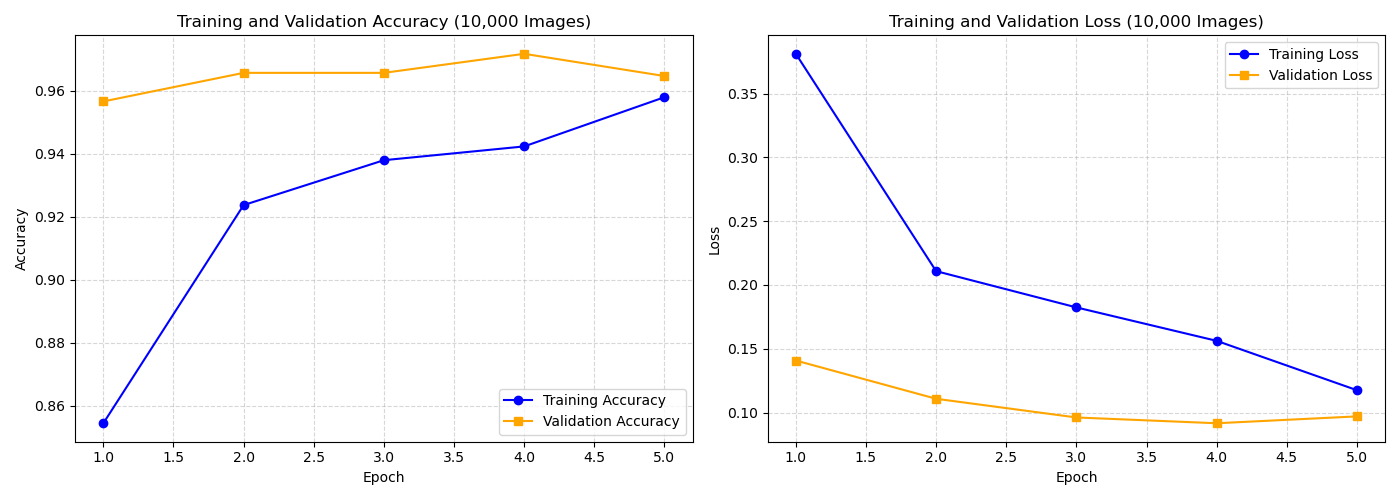

In [43]:
print("Evaluasi Model Test Set:")
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")

from sklearn.metrics import classification_report, confusion_matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Classification Report Test Set:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='s')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='s')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Konversi Model

In [44]:
os.makedirs('submission/saved_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/tfjs_model', exist_ok=True)

inference_model = tf.keras.Sequential([
    model.layers[0]
] + model.layers[2:])

inference_model.build(input_shape=(None, img_height, img_width, 3))

saved_model_path = 'submission/saved_model'
inference_model.export(saved_model_path)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(class_names))

subprocess.run(['tensorflowjs_converter', '--input_format=tf_saved_model', saved_model_path, 'submission/tfjs_model'])

print("Model  dikonversi disimpan di folder 'submission/'")

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_184')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136189746738576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746733200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189749898384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746728208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746739536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746740496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746727056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746740112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746741072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136189746738384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1361

In [45]:
!zip -r submission.zip submission

updating: submission/ (stored 0%)
updating: submission/tfjs_model/ (stored 0%)
updating: submission/tfjs_model/group1-shard2of6.bin (deflated 8%)
updating: submission/tfjs_model/group1-shard3of6.bin (deflated 7%)
updating: submission/tfjs_model/group1-shard1of6.bin (deflated 8%)
updating: submission/tfjs_model/group1-shard6of6.bin (deflated 8%)
updating: submission/tfjs_model/model.json (deflated 90%)
updating: submission/tfjs_model/group1-shard4of6.bin (deflated 7%)
updating: submission/tfjs_model/group1-shard5of6.bin (deflated 8%)
updating: submission/tflite/ (stored 0%)
updating: submission/tflite/model.tflite (deflated 8%)
updating: submission/tflite/label.txt (stored 0%)
updating: submission/saved_model/ (stored 0%)
updating: submission/saved_model/fingerprint.pb (stored 0%)
updating: submission/saved_model/saved_model.pb (deflated 86%)
updating: submission/saved_model/variables/ (stored 0%)
updating: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
upd

## Inference (Optional)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


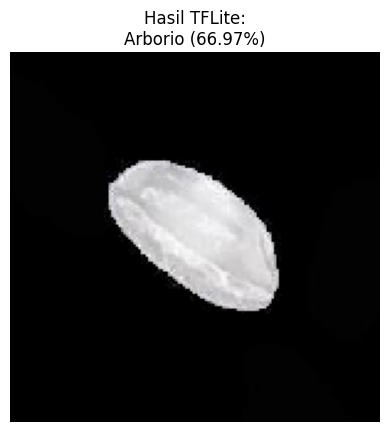

In [46]:

interpreter = tf.lite.Interpreter(model_path="submission/tflite/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ambil 1 gambar acak
all_image_paths = list(data_dir.rglob('*.jpg')) + list(data_dir.rglob('*.jpeg')) + list(data_dir.rglob('*.png'))
test_image_path = random.choice(all_image_paths)

img = image.load_img(test_image_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

predicted_class_idx = np.argmax(output_data[0])
confidence = np.max(output_data[0]) * 100

plt.imshow(img)
plt.axis('off')
plt.title(f"Hasil TFLite:\n{class_names[predicted_class_idx]} ({confidence:.2f}%)")
plt.show()